# 03 · Product Analytics
KPIs, funnels, feature adoption, segmentation, cohort retention and churn drivers. All logic lives in `src/analysis`
and is mirrored in `sql/03`–`sql/08` (reconciled by `src/data/validate_sql_vs_python.py`).
All relationships shown are **observational associations**, not causal effects.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60, "display.width", 200, "display.float_format", "{:,.4f}".format)

from src.utils.io import load_all
from src.utils.config import FIGURES_DIR, PLAN_ORDER
from src.utils.plotting import set_style
from src.analysis import marts, kpis, funnel, feature_adoption as fa, segmentation as seg, retention as ret, churn
set_style()
t = load_all()
af, thresholds = marts.build_account_features(t)
af.shape

(500, 57)

## 1. Product & revenue KPIs

In [2]:
u = fa.usage_with_accounts(t, af)
fs = fa.feature_summary(u, len(af))
monthly = kpis.monthly_metrics(t)
kpis.headline_kpis(t, af, monthly, fs)

,area,metric,value,formula
0,Accounts,Total accounts,500.0000,COUNT(DISTINCT account_id)
1,Accounts,New accounts 2023,227.0000,accounts with signup_date in 2023
2,Accounts,New accounts 2024,273.0000,accounts with signup_date in 2024
3,Revenue,Active subscriptions at snapshot,"4,514.0000",subscriptions with end_date IS NULL
4,Revenue,MRR at snapshot ($),"10,159,608.0000",SUM(mrr_amount) of active subscriptions
5,Revenue,ARR at snapshot ($),"121,915,296.0000",SUM(arr_amount) of active subscriptions = 12 x...
6,Revenue,ARPA ($/month),"20,319.2160",MRR / paying accounts
7,Revenue,Revenue per paid seat ($/month),89.5814,MRR / SUM(seats) of active paid subscriptions
8,Conversion,Accounts that ever started a trial,403.0000,accounts with >=1 is_trial subscription
9,Conversion,Trial-to-paid conversion rate,0.9429,trial accounts with a paid subscription starti...


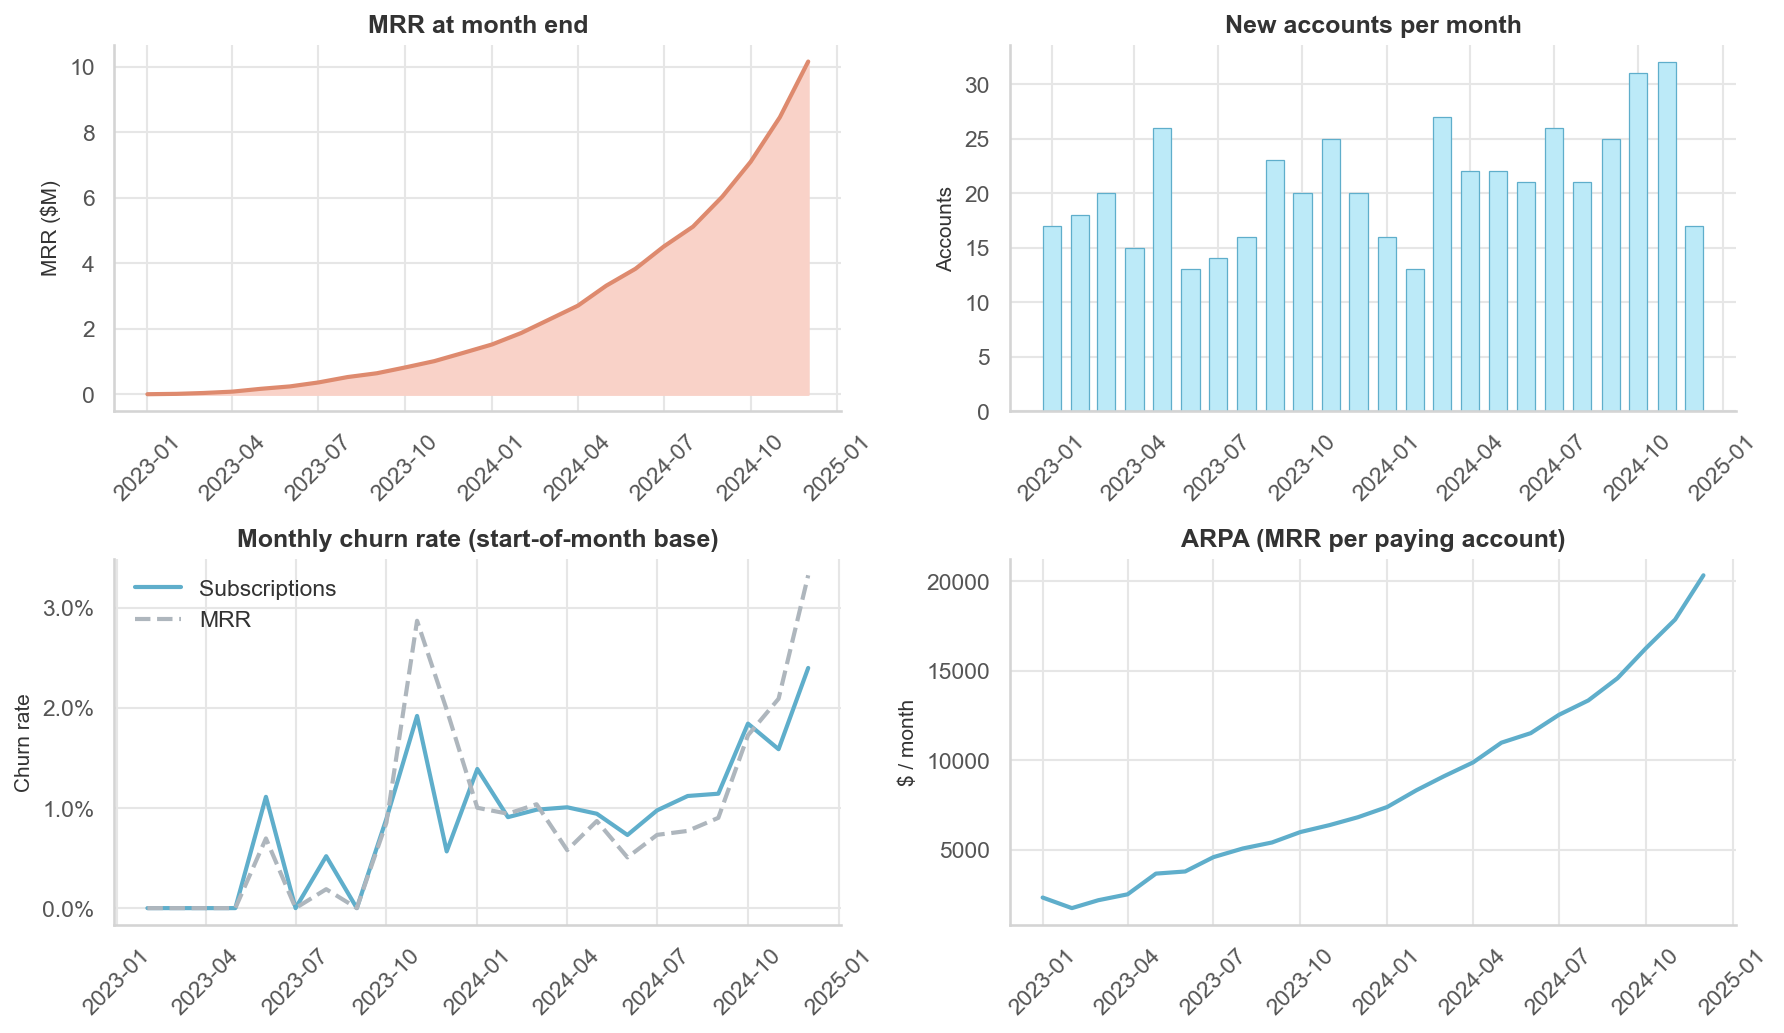

,month,mrr,paying_accounts,active_subscriptions,arpa,subscription_churn_rate,gross_mrr_churn_rate
18,2024-07-01,4513192,360,2055,"12,536.6444",0.0098,0.0073
19,2024-08-01,5120881,384,2364,"13,335.6276",0.0112,0.0077
20,2024-09-01,6035345,414,2769,"14,578.1280",0.0114,0.0090
21,2024-10-01,7098896,437,3215,"16,244.6133",0.0184,0.0172
22,2024-11-01,8460824,474,3754,"17,849.8397",0.0159,0.0209
23,2024-12-01,10159608,500,4514,"20,319.2160",0.0240,0.0332


In [3]:
kpis.plot_monthly(monthly)
display(Image(FIGURES_DIR / "01_monthly_kpis.png"))
monthly[["month", "mrr", "paying_accounts", "active_subscriptions", "arpa", "subscription_churn_rate", "gross_mrr_churn_rate"]].tail(6)

**Read with care:** MRR grows from about $1.26M (Dec 2023) to $10.16M (Dec 2024) because subscriptions accumulate as
concurrent line items (on average 9 active per account at the snapshot) while few end. Every account holds an active
paid subscription on 2024-12-31, including the 110 accounts flagged as churned, so revenue KPIs describe the data as
recorded rather than a clean billing system.

## 2. Funnels

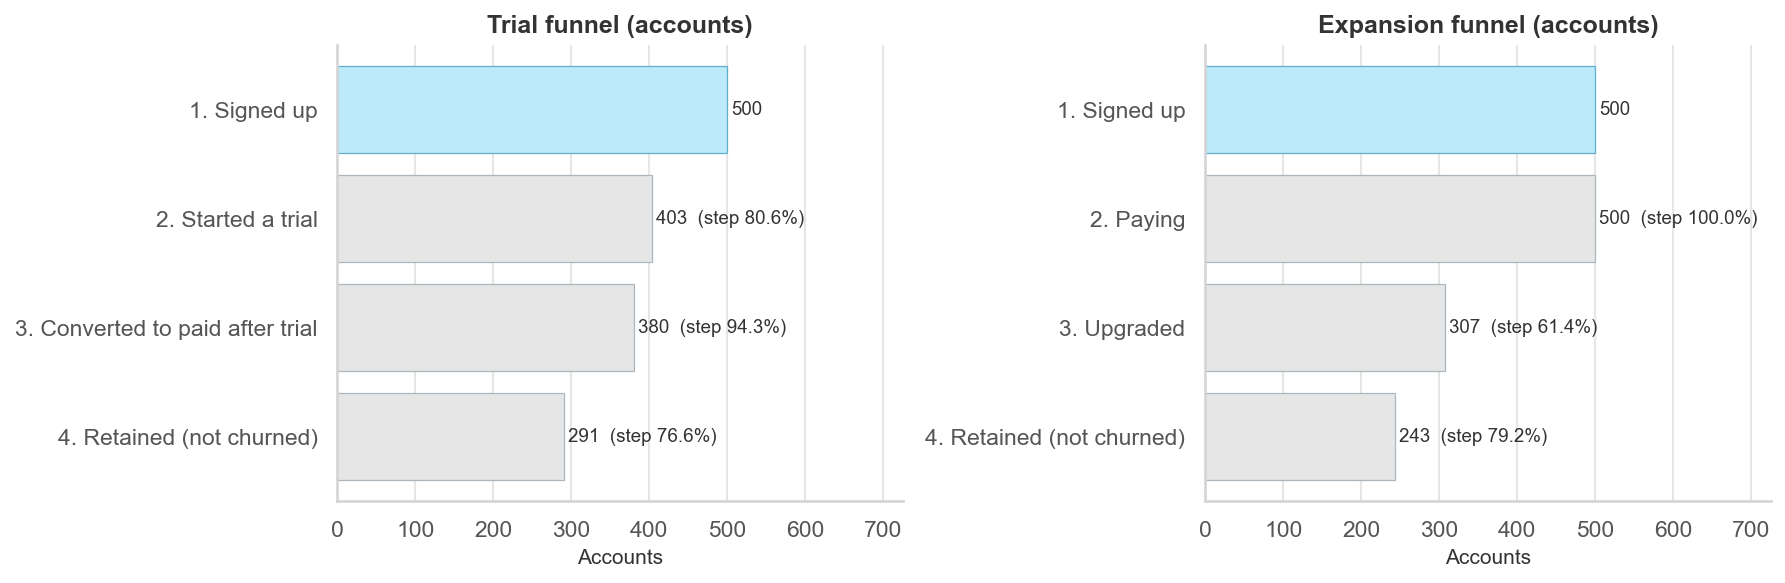

,funnel,stage,accounts,conversion_from_signup,step_conversion,step_drop_off
0,trial,1. Signed up,500,1.0000,NaN,NaN
1,trial,2. Started a trial,403,0.8060,0.8060,0.1940
2,trial,3. Converted to paid after trial,380,0.7600,0.9429,0.0571
3,trial,4. Retained (not churned),291,0.5820,0.7658,0.2342
0,expansion,1. Signed up,500,1.0000,NaN,NaN
1,expansion,2. Paying,500,1.0000,1.0000,0.0000
2,expansion,3. Upgraded,307,0.6140,0.6140,0.3860
3,expansion,4. Retained (not churned),243,0.4860,0.7915,0.2085


{'trial': {'stage': '4. Retained (not churned)',
  'step_drop_off': 0.23421052631578942},
 'expansion': {'stage': '3. Upgraded', 'step_drop_off': 0.386}}

In [4]:
funnels = {name: funnel.funnel_table(af, name) for name in funnel.FUNNELS}
funnel.plot_funnels(funnels)
display(Image(FIGURES_DIR / "02_funnels.png"))
display(pd.concat(funnels.values()))
{name: funnel.largest_bottleneck(ft)[["stage", "step_drop_off"]].to_dict() for name, ft in funnels.items()}

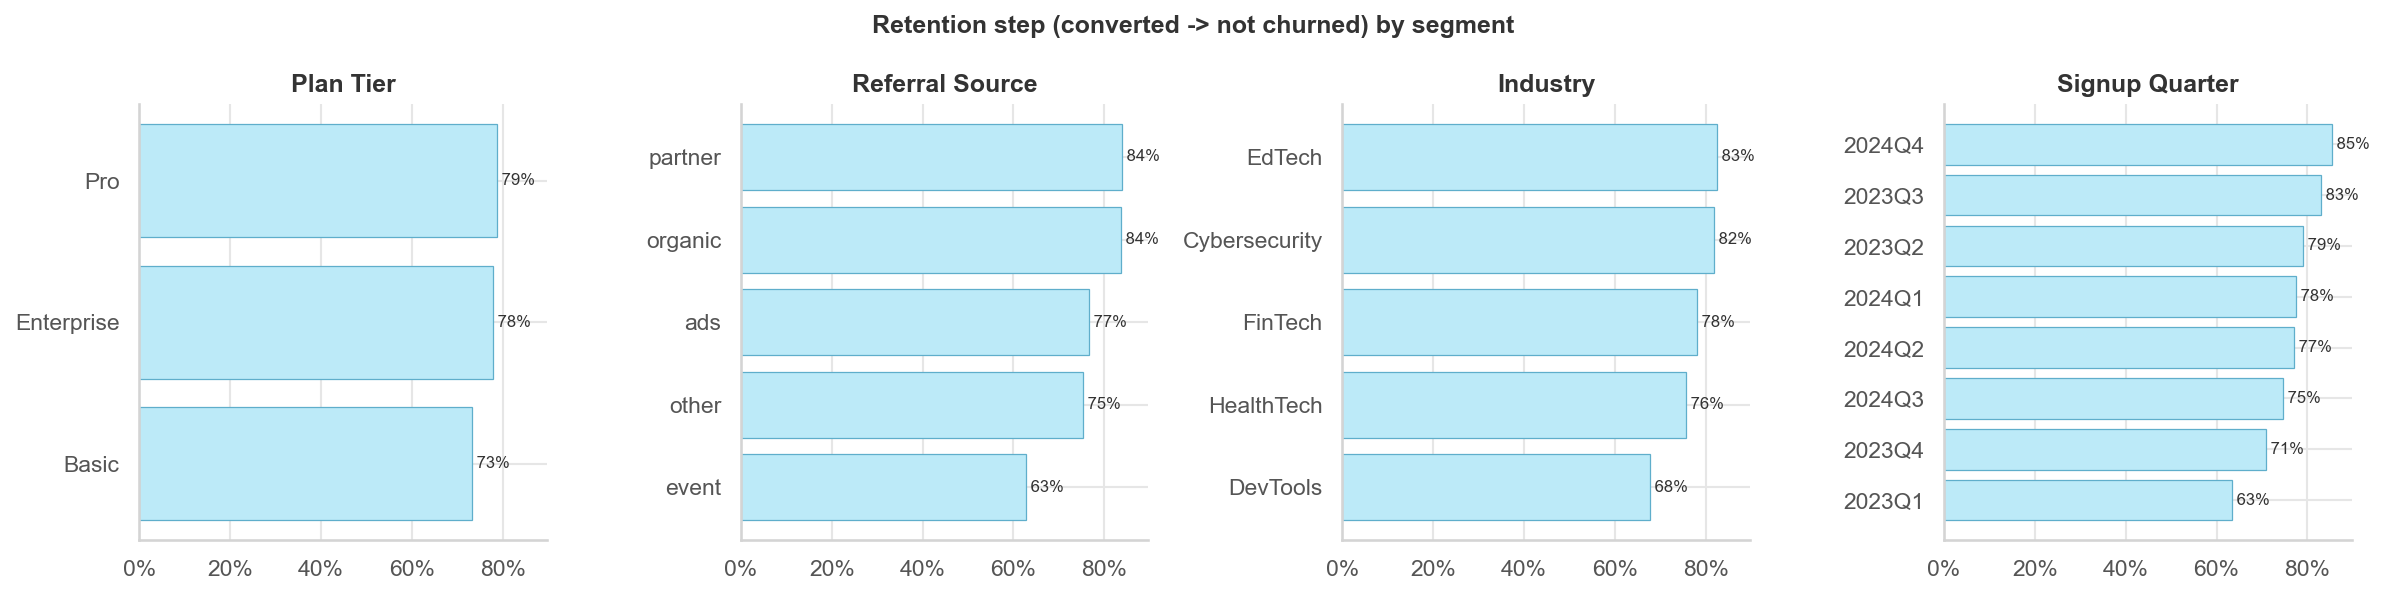

,dimension,segment,accounts,step_conversion
19,referral_source,event,44,0.6286
55,signup_quarter,2023Q1,26,0.6341
39,industry,DevTools,61,0.6778
67,signup_quarter,2023Q4,34,0.7083
3,plan_tier,Basic,96,0.7328
79,signup_quarter,2024Q3,41,0.7455
27,referral_source,other,61,0.7531
51,industry,HealthTech,56,0.7568


In [5]:
seg_trial = funnel.funnel_by_segment(af, "trial")
funnel.plot_conversion_by_segment(seg_trial, "3. Converted to paid after trial", "Trial-to-paid step conversion by segment", "03a_trial_conversion_by_segment")
funnel.plot_conversion_by_segment(seg_trial, "4. Retained (not churned)", "Retention step (converted -> not churned) by segment", "03b_funnel_retention_step_by_segment")
display(Image(FIGURES_DIR / "03b_funnel_retention_step_by_segment.png"))
seg_trial[seg_trial.stage.str.startswith("4")].sort_values("step_conversion")[["dimension", "segment", "accounts", "step_conversion"]].head(8)

The classic Signup → Onboarding → Activation → Trial → Paid funnel is not observable (no onboarding/activation events;
all accounts pay). In the trial funnel the largest step drop-off is **after** conversion (converted → not churned),
not at trial-to-paid.

## 3. Feature adoption & usage behaviour

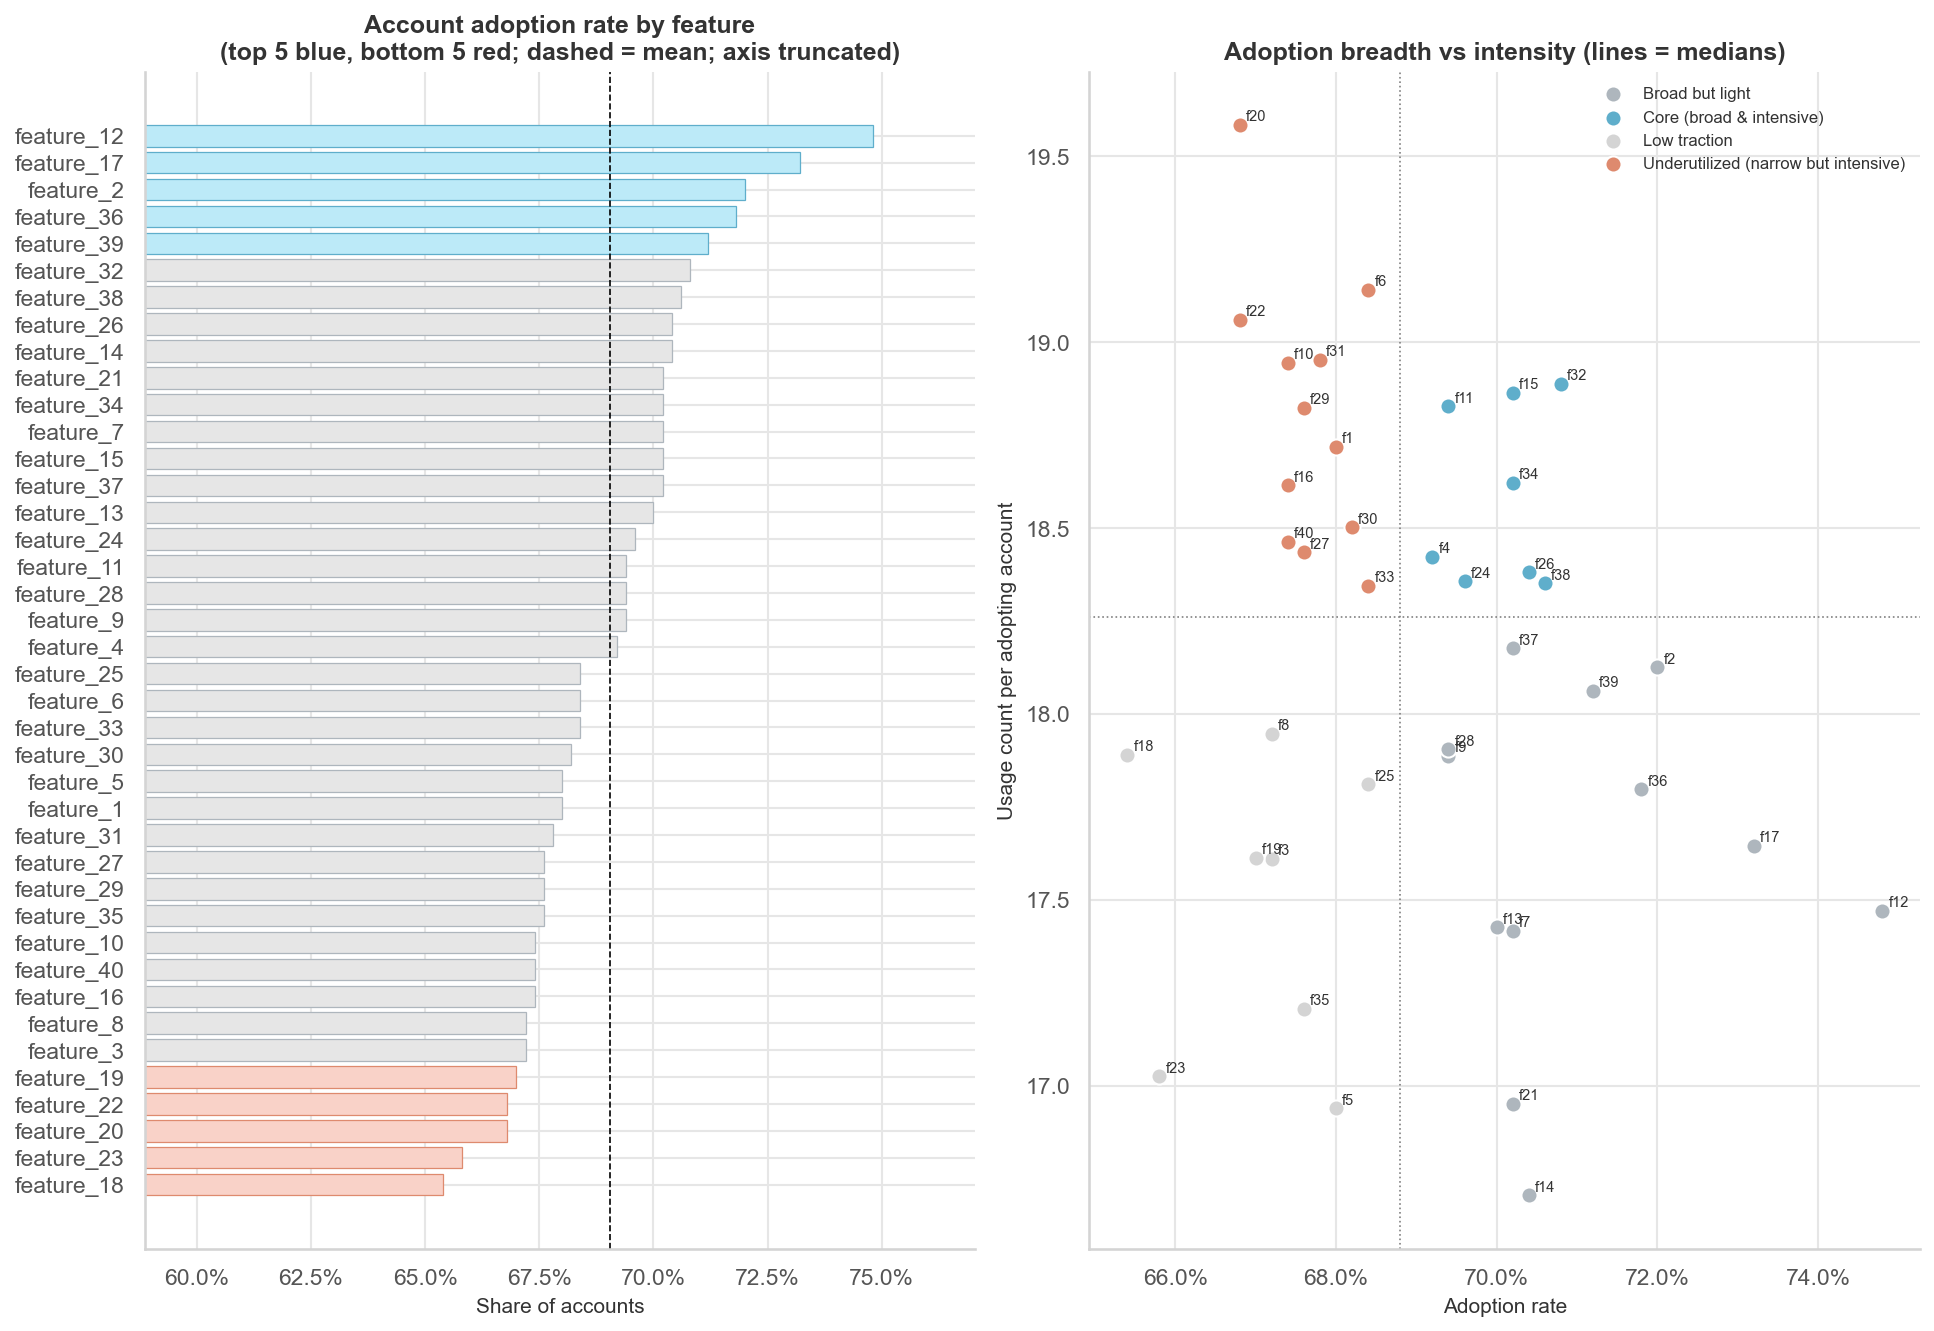

,feature_name,adopting_accounts,adoption_rate,events_per_adopting_account,usage_count_per_adopting_account,errors_per_100_uses,adoption_quadrant
0,feature_12,374,0.7480,1.7620,17.4706,5.4943,Broad but light
1,feature_17,366,0.7320,1.7787,17.6448,5.7138,Broad but light
2,feature_2,360,0.7200,1.7833,18.1250,6.1456,Broad but light
3,feature_36,359,0.7180,1.8050,17.7967,5.8069,Broad but light
4,feature_39,356,0.7120,1.7725,18.0618,5.5521,Broad but light
5,feature_32,354,0.7080,1.8616,18.8870,5.3395,Core (broad & intensive)
6,feature_38,353,0.7060,1.8215,18.3513,5.4955,Core (broad & intensive)
7,feature_14,352,0.7040,1.7045,16.7045,5.2211,Broad but light
8,feature_26,352,0.7040,1.8438,18.3807,6.4451,Core (broad & intensive)
9,feature_7,351,0.7020,1.7635,17.4160,5.0875,Broad but light


In [6]:
fa.plot_feature_adoption(fs)
display(Image(FIGURES_DIR / "04_feature_adoption.png"))
fs[["feature_name", "adopting_accounts", "adoption_rate", "events_per_adopting_account", "usage_count_per_adopting_account", "errors_per_100_uses", "adoption_quadrant"]]

In [7]:
by_plan = fa.adoption_matrix(u, "subscription_plan_tier", PLAN_ORDER)
fa.plot_adoption_heatmap(by_plan, "Feature adoption within plan tier\n(share of accounts with usage on that tier)", "10_feature_adoption_by_plan")
display(fa.plan_usage_profile(u, t["subscriptions"]))
display(fa.beta_comparison(u))
print("max within-plan adoption gap across features:", round((by_plan.max(axis=1) - by_plan.min(axis=1)).max(), 3))

,plan_tier,usage_events,subscriptions_with_usage,accounts_with_usage,total_usage_count,total_errors,avg_minutes_per_event,subscriptions,events_per_subscription,distinct_features_per_subscription,errors_per_100_uses
0,Basic,7980,1588,479,79888,4435,50.3125,1602,4.9813,4.7311,5.5515
1,Pro,8440,1665,474,84561,4817,50.6301,1675,5.0388,4.7694,5.6965
2,Enterprise,8580,1714,478,86076,4855,51.1391,1723,4.9797,4.6949,5.6404


,is_beta_feature,usage_events,mean_usage_count,mean_minutes,mean_errors_per_event,share_events_with_error,errors_per_100_uses
0,False,22456,10.0169,50.6897,0.5651,0.3096,5.6420
1,True,2544,10.0574,50.8238,0.5566,0.3058,5.5343


max within-plan adoption gap across features: 0.09


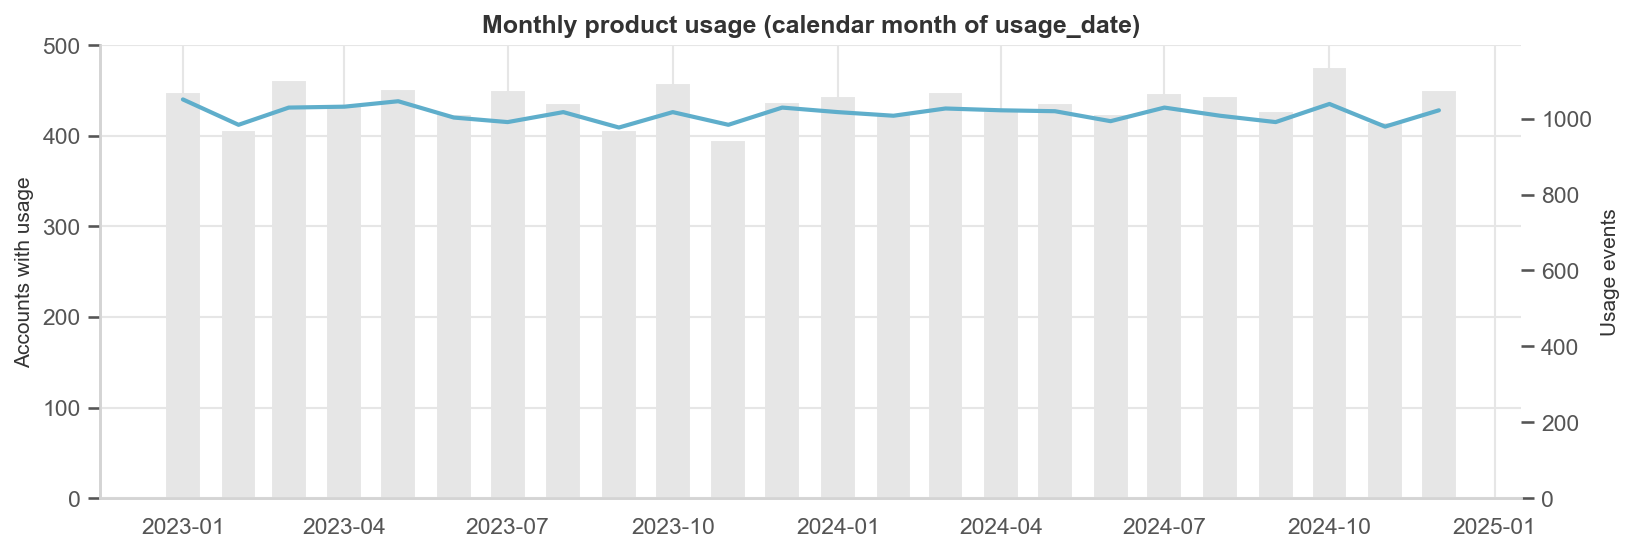

In [8]:
mu = fa.monthly_usage(u)
fa.plot_monthly_usage(mu)
display(Image(FIGURES_DIR / "05_monthly_usage.png"))

Adoption is tightly clustered (65.4%–74.8% of accounts per feature) with no dominant or neglected feature, and usage
per plan is nearly identical. Monthly active accounts are flat across 2023–2024 even though half of the accounts signed
up in 2024 — another sign that usage dates are not lifecycle-aligned.

## 4. Engagement segmentation

,segment,rule
0,Power Accounts,total_usage_count >= 619 (P75) AND distinct_fe...
1,Engaged Accounts,not Power AND total_usage_count >= 498 (P50)
2,Casual Accounts,373 (P25) <= total_usage_count < 498 (P50)
3,Low-Engagement Accounts,total_usage_count < 373 (P25)
4,high_friction (overlay),error_rate >= 0.0658 (P75) OR any escalated ti...


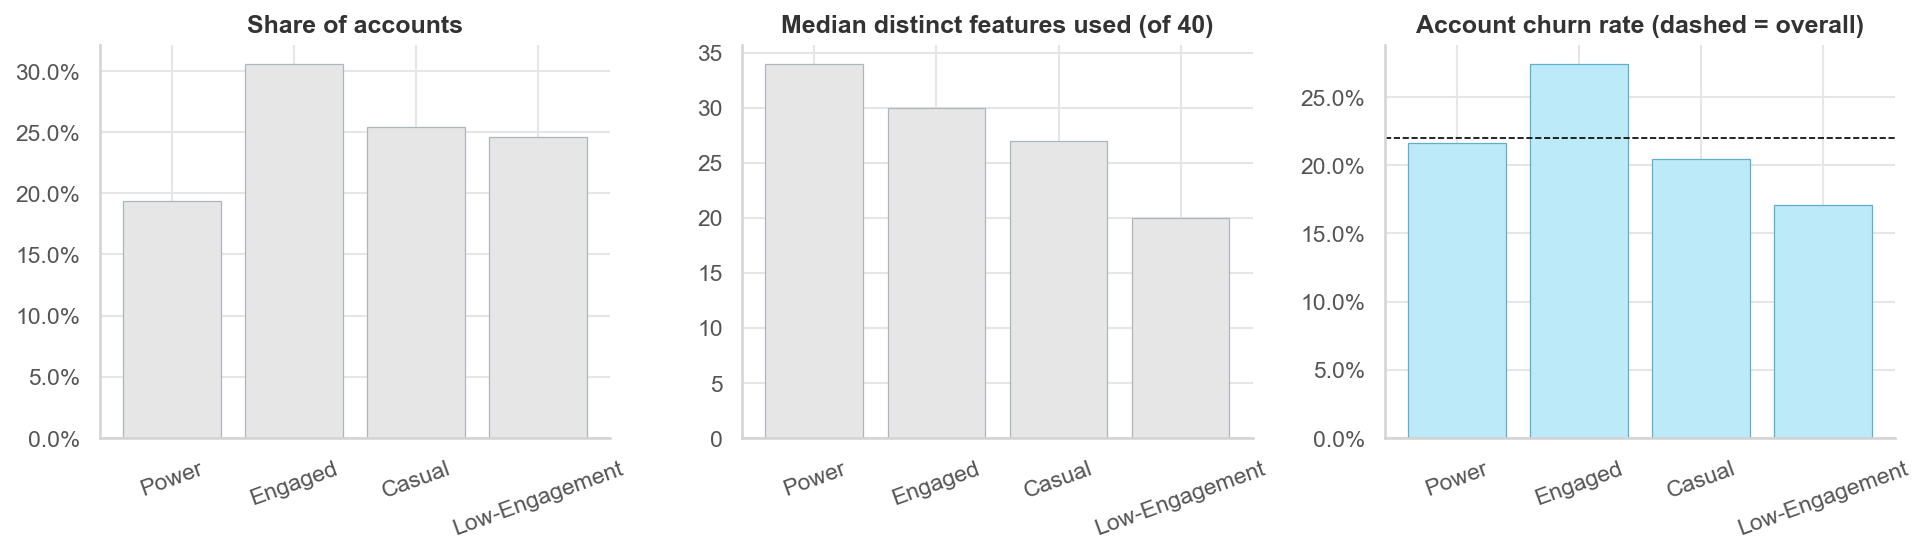

,engagement_segment,accounts,median_usage_count,median_distinct_features,median_duration_hours,mean_error_rate,mean_tickets,high_friction_share,mrr_at_snapshot,churn_rate,share_of_accounts
0,Power Accounts,97,709.0000,34.0000,59.6336,0.0565,3.8041,0.3299,2779239,0.2165,0.1940
1,Engaged Accounts,153,574.0000,30.0000,48.1064,0.0566,4.0850,0.3987,3382563,0.2745,0.3060
2,Casual Accounts,127,439.0000,27.0000,37.0997,0.0556,4.0236,0.3150,2498967,0.2047,0.2540
3,Low-Engagement Accounts,123,296.0000,20.0000,24.8308,0.0572,4.0244,0.4390,1498839,0.1707,0.2460


In [9]:
display(seg.segment_rules_table(thresholds))
profile = seg.segment_profile(af)
seg.plot_segments(profile, af.churn_flag.mean())
display(Image(FIGURES_DIR / "11_engagement_segments.png"))
profile

In [10]:
# Does clustering add value over the rules? (standardized behavioural features, k-means)
seg.clustering_check(af)

,k,silhouette,smallest_cluster_share
0,2,0.2710,0.4400
1,3,0.1889,0.2920
2,4,0.1962,0.0940
3,5,0.1991,0.0940
4,6,0.2014,0.0720


Best silhouette is about 0.27 (k = 2), i.e. weak, poorly separated structure, so clustering is **not** used; the
interpretable rule-based segments are kept. "Dormant" and "At-Risk" segments are not created because they need
reliable recency data.

## 5. Cohort retention

,group,window_days,eligible,retained,retention_rate
0,All,1,4955,4947,0.9984
1,All,7,4751,4697,0.9886
2,All,14,4523,4438,0.9812
3,All,30,4066,3962,0.9744
4,All,60,3450,3334,0.9664
5,All,90,2954,2831,0.9584


,group,day,km_survival,n
0,All,1,0.9950,5000
1,All,7,0.9826,5000
2,All,14,0.9708,5000
3,All,30,0.9552,5000
4,All,60,0.9346,5000
5,All,90,0.9215,5000


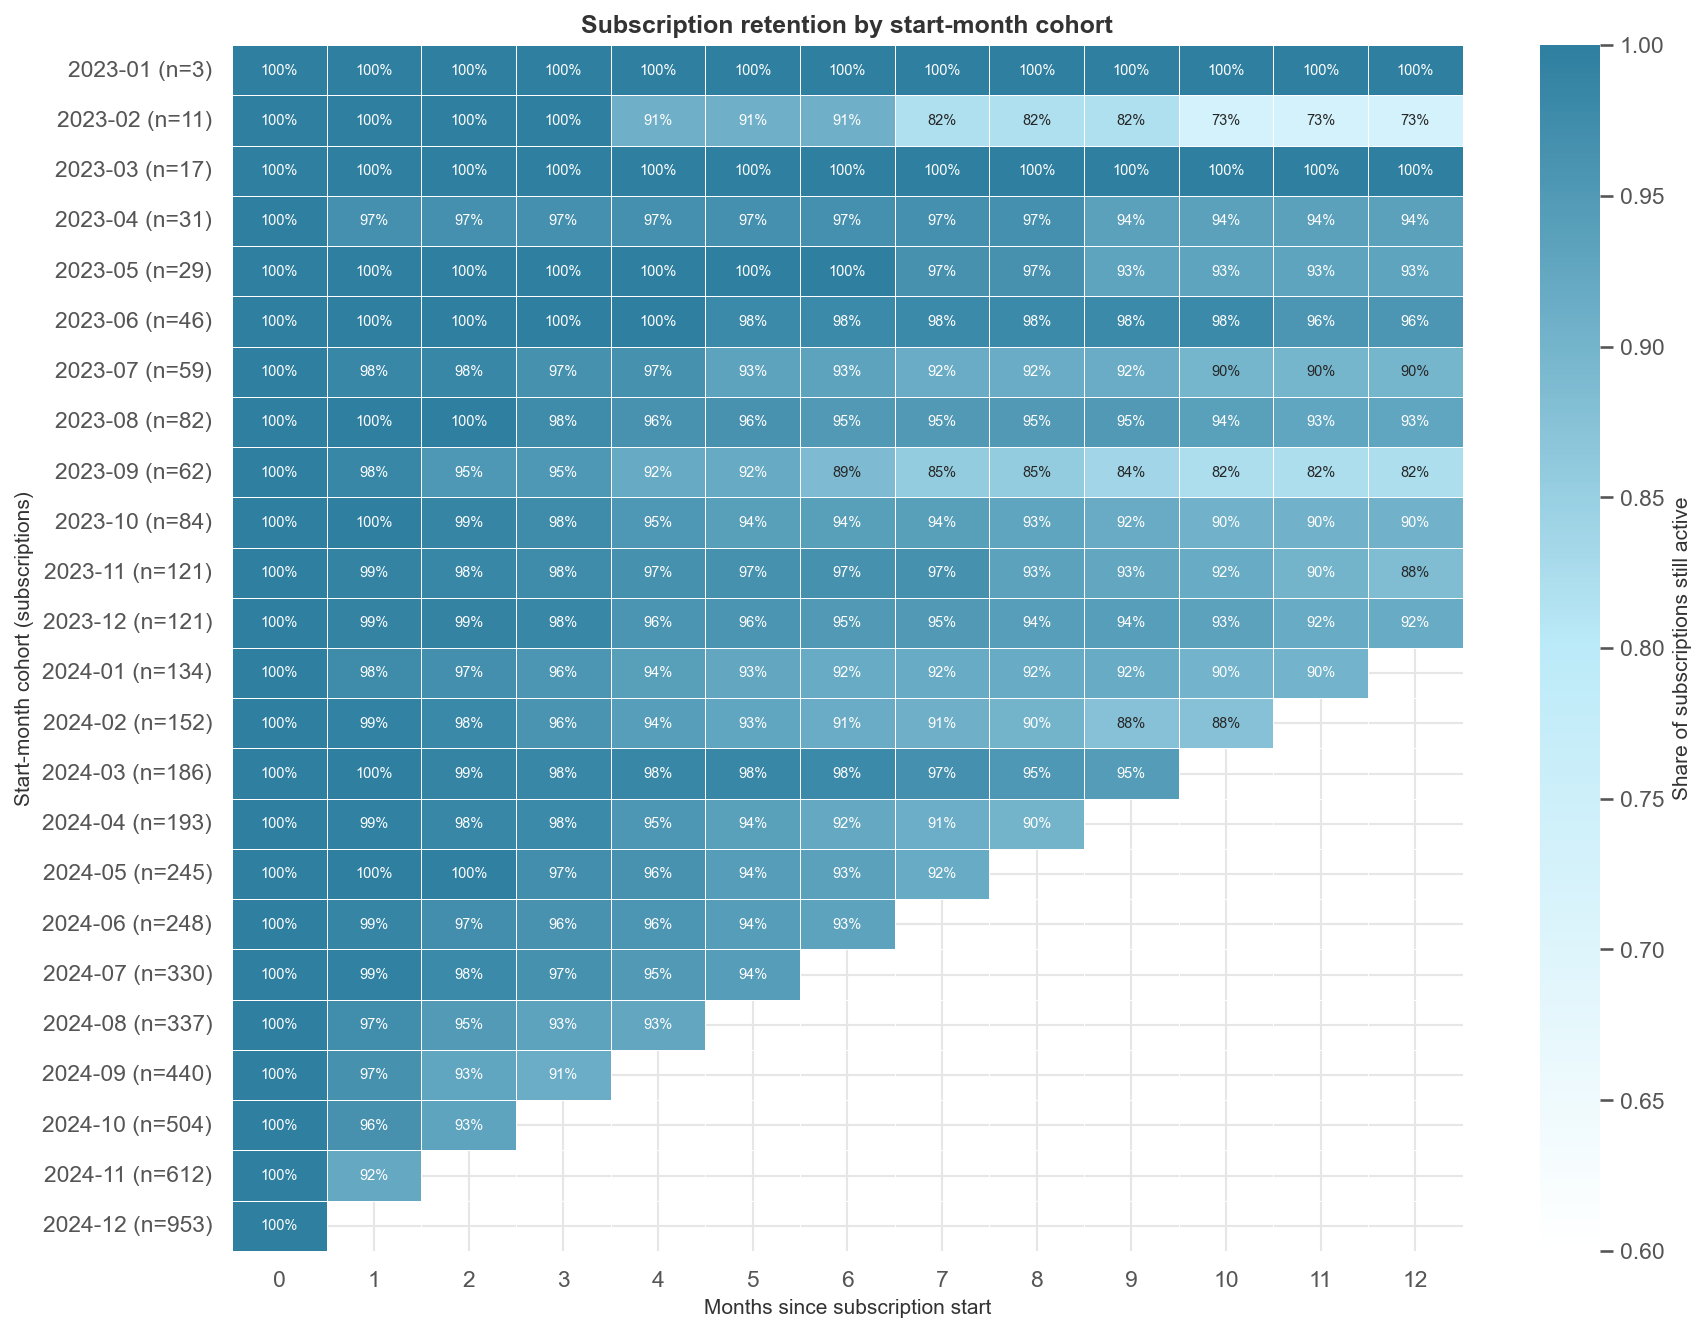

In [11]:
s = ret.subscription_frame(t, af)
a = ret.account_frame(af)
display(ret.subscription_window_retention(s))
display(ret.kaplan_meier(s, "duration_days", "churn_flag", ret.SUB_WINDOWS))
cm = ret.monthly_cohort_matrix(s)
ret.plot_cohort_heatmap(cm)
display(Image(FIGURES_DIR / "06_cohort_retention_heatmap.png"))

In [12]:
display(ret.quarterly_cohort_retention(s))
display(ret.subscription_window_retention(s, "plan_tier").query("window_days == 90"))
display(ret.subscription_window_retention(s, "referral_source").query("window_days == 90"))

window_days,1,7,14,30,60,90
group,,,,,,
2023Q1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2023Q2,1.0000,0.9906,0.9906,0.9906,0.9906,0.9906
2023Q3,1.0000,0.9951,0.9951,0.9901,0.9852,0.9655
2023Q4,1.0000,1.0000,1.0000,0.9939,0.9908,0.9785
2024Q1,1.0000,0.9979,0.9979,0.9915,0.9809,0.9682
2024Q2,1.0000,0.9985,0.9971,0.9942,0.9840,0.9708
2024Q3,1.0000,0.9964,0.9901,0.9774,0.9521,0.9350
2024Q4,0.9960,0.9747,0.9567,0.9419,0.9306,0.9565


,dimension,group,window_days,eligible,retained,retention_rate
5,plan_tier,Basic,90,965,925,0.9585
11,plan_tier,Enterprise,90,1005,965,0.9602
17,plan_tier,Pro,90,984,941,0.9563


,dimension,group,window_days,eligible,retained,retention_rate
5,referral_source,ads,90,662,632,0.9547
11,referral_source,event,90,523,501,0.9579
17,referral_source,organic,90,627,603,0.9617
23,referral_source,other,90,593,566,0.9545
29,referral_source,partner,90,549,529,0.9636


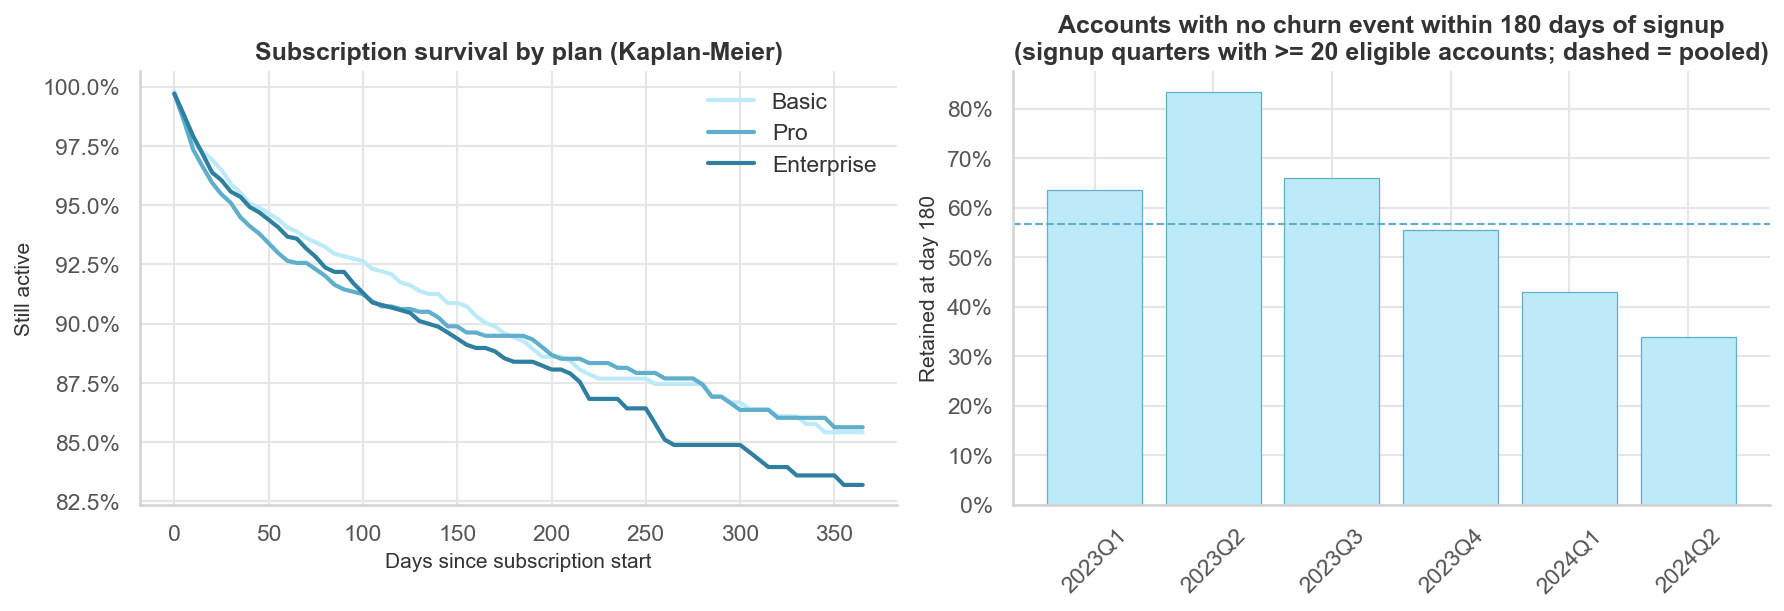

window_days,30,60,90,180,365
group,,,,,
2023Q1,0.9091,0.8909,0.8182,0.6364,0.3636
2023Q2,0.9815,0.9444,0.8704,0.8333,0.7037
2023Q3,0.9245,0.8868,0.8491,0.6604,0.3962
2023Q4,0.8923,0.8000,0.7385,0.5538,0.2308
2024Q1,0.8571,0.7679,0.6964,0.4286,1.0000
2024Q2,0.8154,0.6308,0.5385,0.3385,NaN
2024Q3,0.7083,0.5694,0.4167,0.0000,NaN
2024Q4,0.6667,0.4062,0.0000,NaN,NaN


window_days,30,60,90,180,365
group,,,,,
Q1 (lowest),0.8218,0.7283,0.7037,0.4925,0.4390
Q2,0.8218,0.7766,0.7000,0.5676,0.3400
Q3,0.8690,0.7464,0.6692,0.6036,0.4730
Q4 (highest),0.8235,0.7344,0.6777,0.5556,0.3968


In [13]:
acc_q = ret.account_window_retention(a, "signup_quarter")
km_plan = ret.kaplan_meier(s, "duration_days", "churn_flag", list(range(0, 366, 5)), "plan_tier")
ret.plot_retention_curves(km_plan, acc_q)
display(Image(FIGURES_DIR / "07_retention_curves.png"))
display(acc_q.pivot(index="group", columns="window_days", values="retention_rate"))
display(ret.account_window_retention(a, "breadth_quartile").pivot(index="group", columns="window_days", values="retention_rate"))

* Subscriptions: D90 retention is 95.8% (eligible-cohort method). The 2024Q3 start cohort is the weakest at D90.
  Plan and channel differences are within about 2 pp.
* Accounts: newer signup cohorts reach their first churn event sooner, **but** churn events are concentrated in late
  2024 for every cohort (events per 100 accounts rise from 10.9 in 2023Q1 to 50.0 in 2024Q4). This calendar effect
  confounds the cohort comparison, so it is not evidence that newer customers are worse.
* Feature breadth quartiles show no consistent retention gradient.

## 6. Churn drivers

,dimension,chi2,dof,p_value,cramers_v,min_expected_count,groups,p_holm,significant_after_holm
2,industry,8.8232,4,0.0657,0.1328,17.3800,5,1.0000,False
4,referral_source,8.3566,4,0.0794,0.1293,19.5800,5,1.0000,False
9,usage_quartile,5.2925,3,0.1516,0.1029,27.0600,4,1.0000,False
7,engagement_segment,4.5688,3,0.2062,0.0956,21.3400,4,1.0000,False
12,high_friction,1.5835,1,0.2083,0.0563,41.1400,2,1.0000,False
8,breadth_quartile,4.3298,3,0.2280,0.0931,23.1000,4,1.0000,False
6,tenure_bucket,4.2849,3,0.2323,0.0926,24.8600,4,1.0000,False
1,highest_plan_tier,1.3019,1,0.2539,0.0510,4.6200,2,1.0000,False
14,has_trial_subscription,1.0991,1,0.2945,0.0469,21.3400,2,1.0000,False
13,is_trial,0.7443,1,0.3883,0.0386,21.3400,2,1.0000,False


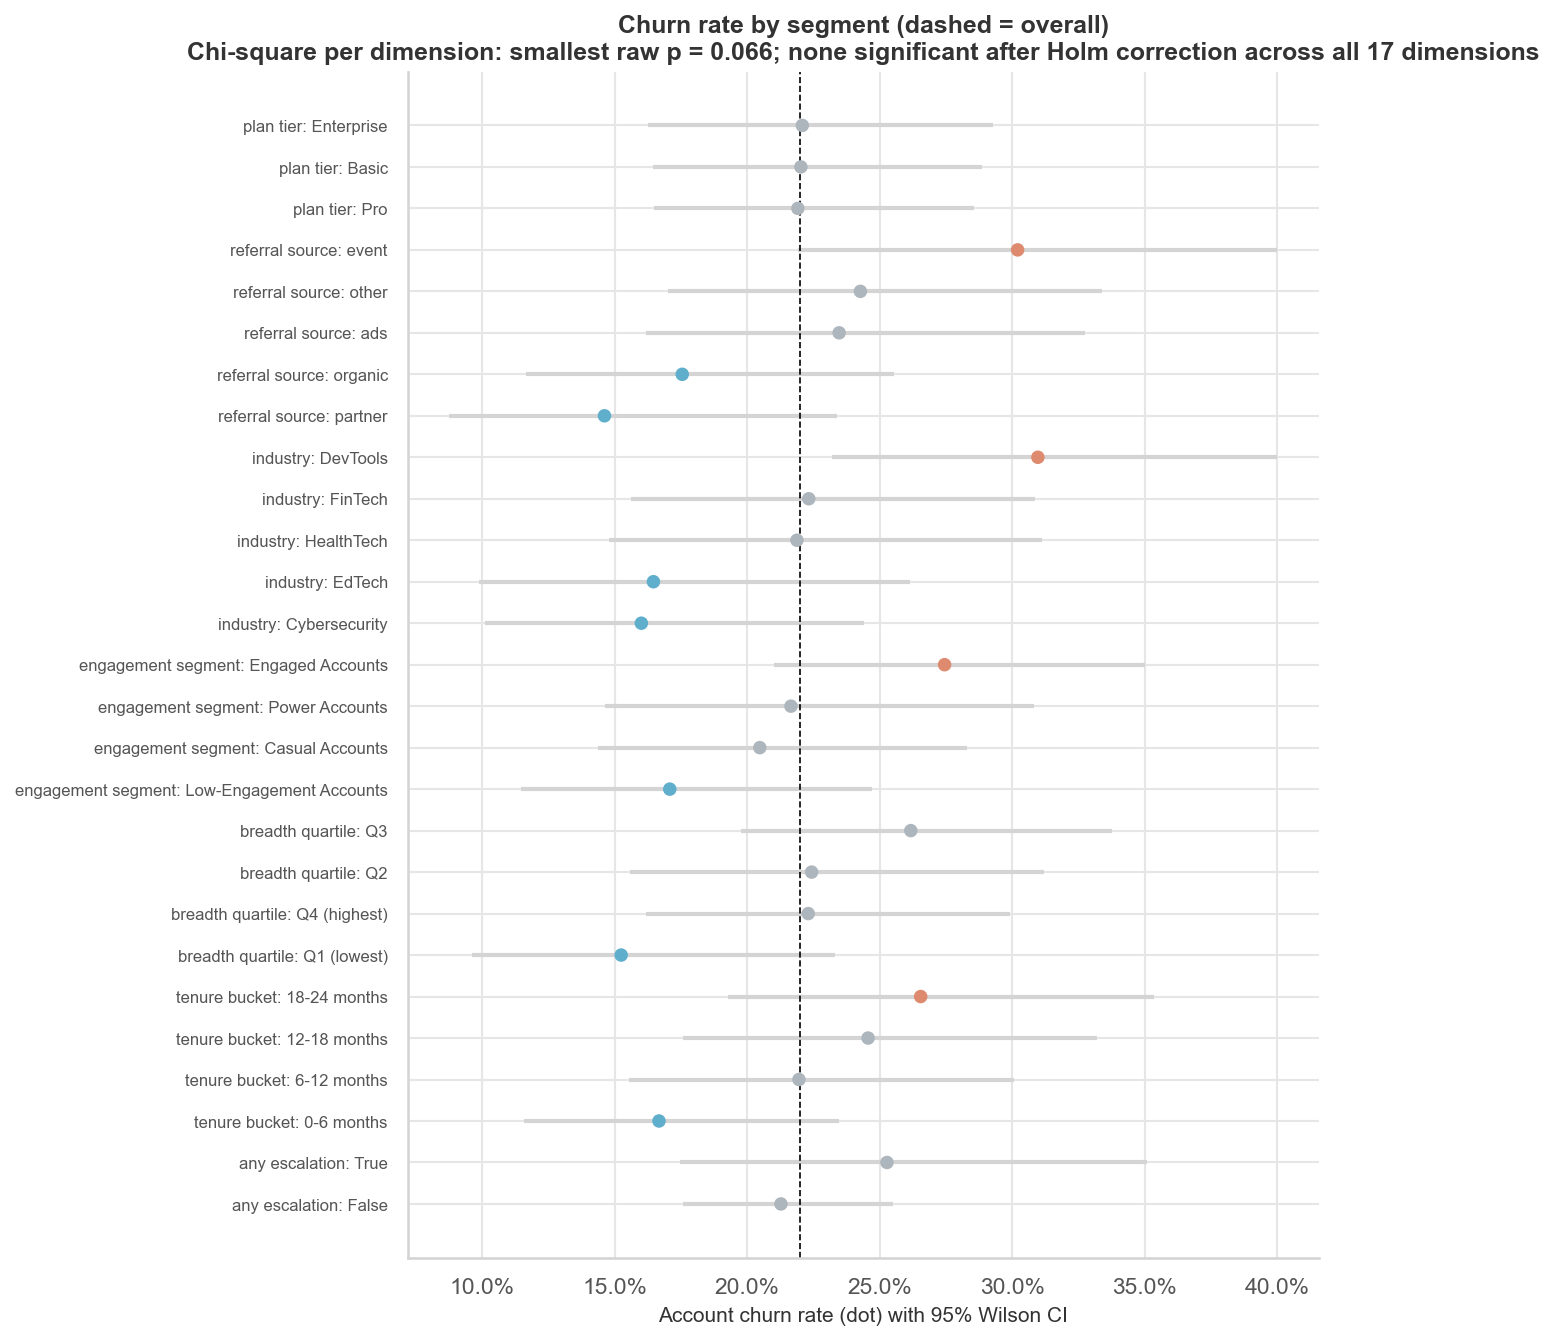

In [14]:
drivers, dim_tests = churn.churn_by_dimension(af)
display(dim_tests)
churn.plot_churn_drivers(drivers, dim_tests, af.churn_flag.mean(), ["plan_tier", "referral_source", "industry", "engagement_segment", "breadth_quartile", "tenure_bucket", "any_escalation"])
display(Image(FIGURES_DIR / "08_churn_drivers.png"))

,feature,median_churned,median_retained,mean_churned,mean_retained,n_churned,n_retained,mann_whitney_u,p_value,rank_biserial,p_holm
14,avg_first_response_minutes,82.5000,89.1667,83.1143,88.8798,107,384,"17,970.0000",0.0474,0.1253,0.7583
1,tenure_days,379.5000,301.0000,371.6727,329.4333,110,390,"23,982.0000",0.0585,-0.1180,0.8782
9,error_rate,0.0537,0.0550,0.0539,0.0572,110,390,"19,341.5000",0.1152,0.0983,1.0000
8,total_duration_hours,43.5844,41.4042,43.9854,41.7641,110,390,"23,154.0000",0.2031,-0.0794,1.0000
6,total_usage_count,527.5000,491.0000,522.0364,495.1308,110,390,"23,143.5000",0.2059,-0.0790,1.0000
7,distinct_features,29.0000,28.0000,28.3364,27.4128,110,390,"23,101.0000",0.2166,-0.0770,1.0000
2,n_subscriptions,10.0000,10.0000,10.2909,9.9179,110,390,"22,854.5000",0.2920,-0.0655,1.0000
11,n_tickets,3.5000,4.0000,3.9273,4.0205,110,390,"20,194.5000",0.3419,0.0585,1.0000


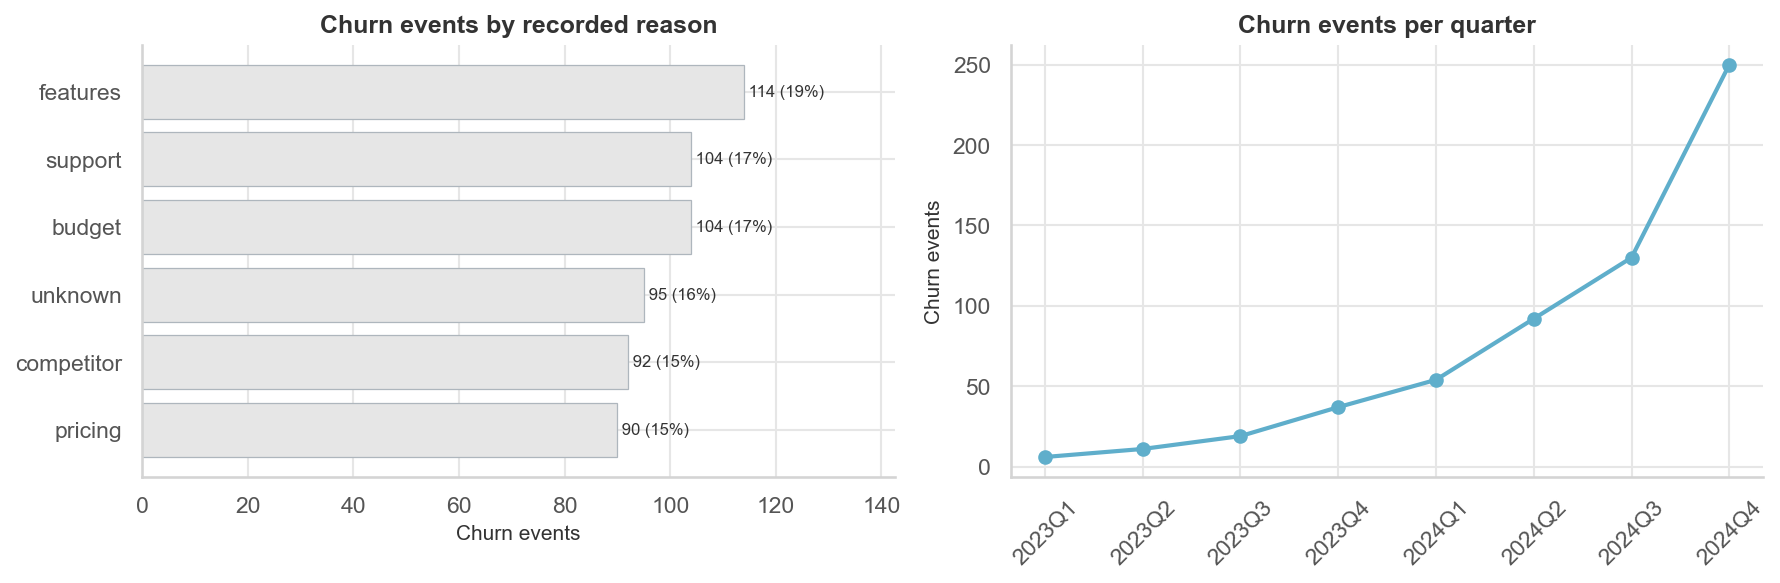

,reason_code,events,accounts,refund_share,total_refund_usd,preceding_upgrade_share,preceding_downgrade_share,reactivation_share,share_of_events
0,features,114,104,0.2105,"1,905.9000",0.1491,0.0789,0.1140,0.1903
1,budget,104,94,0.2308,"1,247.5400",0.2308,0.0577,0.1154,0.1736
2,support,104,95,0.2692,"1,219.6400",0.2692,0.1250,0.0577,0.1736
3,unknown,95,86,0.2737,"1,742.3900",0.2000,0.0947,0.0947,0.1586
4,competitor,92,79,0.1957,"1,203.5300",0.1848,0.1304,0.1304,0.1536
5,pricing,90,86,0.2444,"1,333.2500",0.2000,0.0444,0.1000,0.1503


feedback_text,(no feedback),missing features,switched to competitor,too expensive
reason_code,,,,
budget,28,24,24,28
competitor,20,27,21,24
features,32,27,23,32
pricing,22,20,24,24
support,24,31,20,29
unknown,22,26,24,23


In [15]:
display(churn.numeric_comparison(af).head(8))
reasons = churn.churn_reasons(t, af)
churn.plot_churn_reasons(reasons["reasons"], reasons["events_by_quarter"])
display(Image(FIGURES_DIR / "09_churn_reasons.png"))
display(reasons["reasons"])
display(reasons["reason_vs_feedback"])

**Churn drivers analysis (observational).** Churn is 22.0% overall. The largest gaps are by acquisition channel
(partner 14.6%, event 30.2%) and industry (Cybersecurity 16.0%, DevTools 31.0%), but neither is significant after
Holm correction (raw p = 0.079 and 0.066). Plan tier shows no difference (21.9%–22.1%). Behavioural measures
(usage volume, breadth, errors, tickets, escalations) show no reliable association with churn. Recorded churn reasons
are spread evenly (15%–19% each), and free-text feedback does not match the reason code, which limits the usefulness
of the reason data.